In [ ]:
import pydmr
import dcmri as dc

data_file = dc.fetch('tristan_humans_healthy_rifampicin')
data = pydmr.read(data_file, 'nest')
rois = data['rois']
subjects = list(rois.keys())

In [15]:
from challenge_spiro.utils.score import parse_data

subj_idx, visit_idx = 0, 0

subject = subjects[subj_idx]
visits = list(rois[subject].keys())
visit = visits[visit_idx]
time, signal, settings = parse_data(data_file, subject, visit)

In [ ]:
import numpy as np

def print_recon_err(signal_recon, signal):
    err = []
    for i in range(4):
        err_i = np.linalg.norm(signal_recon[i] - signal[i]) / np.linalg.norm(signal[i])
        err.append(err_i)
    err = max(err)
    print(f"Reconstruction error: {100 * err} %")

In [34]:
from challenge_spiro.solutions.submitted.muzammil import inverse
from challenge_spiro.utils.model import forward

params_recon_submission = inverse(time, signal, **settings)
signal_recon_submission = forward(params_recon_submission, time, **settings)

print_recon_err(signal_recon_submission, signal)

Reconstruction error: 71.40335356096516 %


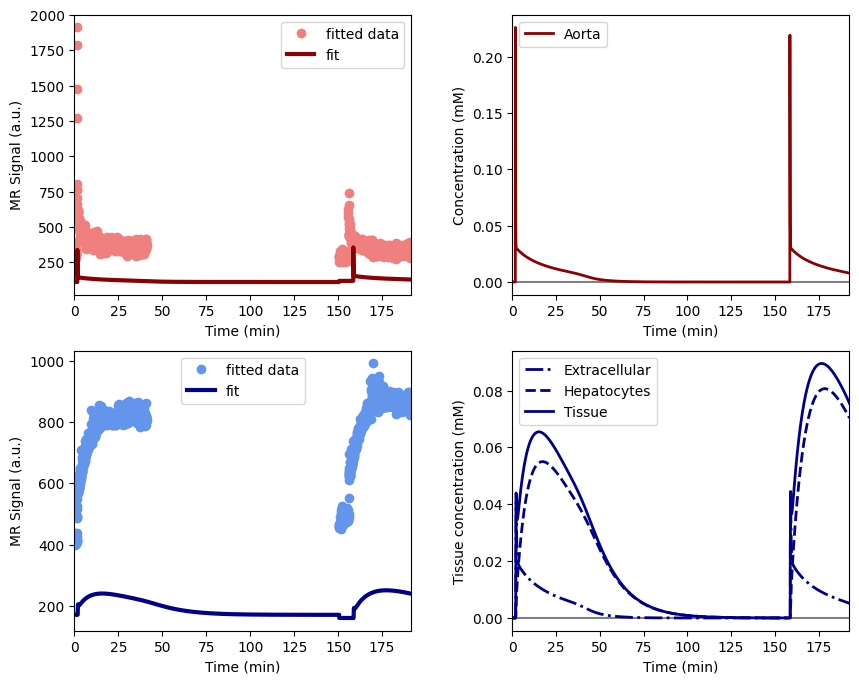

In [37]:
from challenge_spiro.utils.model import plot

plot(params_recon_submission, time, signal, **settings)

In [36]:
from challenge_spiro.solutions.provided.benchmark import inverse
from challenge_spiro.utils.model import forward

params_recon_benchmark = inverse(time, signal, **settings)

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         5.1546e+06                                    1.09e+10    
       1              2         3.4984e+06      1.66e+06       1.77e+03       1.44e+08    
       2              3         2.6796e+06      8.19e+05       9.11e+02       5.95e+07    
       3              4         2.3598e+06      3.20e+05       3.72e+01       6.56e+06    
       4              6         2.3598e+06      0.00e+00       0.00e+00       6.56e+06    
`xtol` termination condition is satisfied.
Function evaluations 6, initial cost 5.1546e+06, final cost 2.3598e+06, first-order optimality 6.56e+06.
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         8.1592e+06                                    7.70e+08    
       1              2         1.0522e+06      7.11e+06       1.43e+03       1.72e+08    
       2              3         3

In [1]:
signal_recon_benchmark = forward(params_recon_benchmark, time, **settings)

print_recon_err(signal_recon_benchmark, signal)

NameError: name 'forward' is not defined

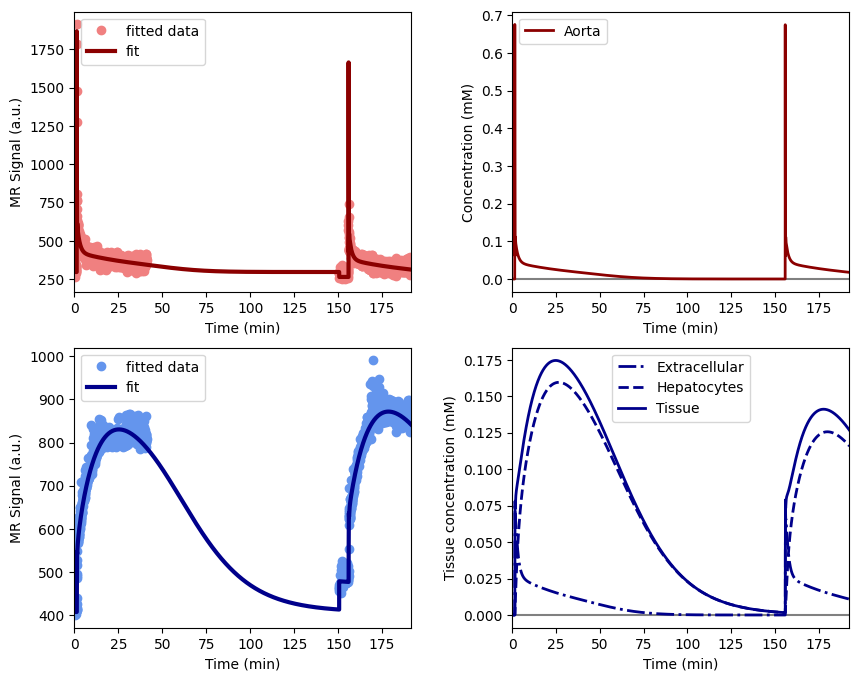

In [ ]:
plot(params_recon_benchmark, time, signal, **settings)